# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZainDev04/Flyrank-ML-Internship/blob/main/work/notebooks/w06_validation_audit.ipynb)

**Lane 3 — Structured Content Archetype Clustering.**

Two jobs. First, read two findings from the FlyRank research paper the way I would want my own work read —
looking for the methodology question, not the mistake. Then turn the same lens on my own ML-08 clustering,
which is the harder half, because I already know where I was generous to myself.

**What this notebook changes about my own work, up front:** one of my six archetypes does not survive its
own robustness test. Section 3 shows it, and section 4 rewrites the claim.

> Skills for this card: `skills/hunting-leakage-and-validating/SKILL.md` +
> `skills/flyrank/flyrank-data/SKILL.md`. Paper: `docs/flyrank-seo-research-march-2026.pdf`.
> Data: `data/raw/content_refresh_anonymized.csv`. Seed 42 throughout.

In [1]:
import os, sys, json, subprocess, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

SEED = 42
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/ZainDev04/Flyrank-ML-Internship"
CSV_REL  = "data/raw/content_refresh_anonymized.csv"
if IN_COLAB and not Path(CSV_REL).exists():
    if not os.path.isdir("Flyrank-ML-Internship"):
        subprocess.run(["git","clone","--depth","1",REPO_URL,"Flyrank-ML-Internship"], check=True)
    os.chdir("Flyrank-ML-Internship")
else:
    here = Path.cwd()
    for c in [here, *here.parents]:
        if (c / CSV_REL).exists():
            os.chdir(c); break
assert Path(CSV_REL).exists()
pd.set_option("display.width", 190); pd.set_option("display.max_columns", 40)

MIN_IMPRESSIONS, K = 300, 6            # both frozen from ML-02/ML-08
df = pd.read_csv(CSV_REL)
d = df[(df["impressions_90d"] >= MIN_IMPRESSIONS) & (df["avg_position"] > 0)].copy()
d["log_impressions"] = np.log1p(d["impressions_90d"])
d["log_clicks"] = np.log1p(d["clicks_90d"])
d["log_sessions"] = np.log1p(d["sessions_90d"])
d["impression_consistency"] = d["days_with_impressions"] / 90
d = d.reset_index(drop=True)

FEATURES = ["log_impressions","log_clicks","ctr","avg_position","log_sessions",
            "engagement_rate","impression_consistency","content_age_days","days_since_last_update"]
scaler = StandardScaler().fit(d[FEATURES].fillna(d[FEATURES].median()))
X = scaler.transform(d[FEATURES].fillna(d[FEATURES].median()))
base_labels = KMeans(n_clusters=K, n_init=25, random_state=SEED).fit_predict(X)
d["cluster"] = base_labels

NAMES = {0:"Long-Tenured Plateau", 1:"Long-Form Untouched", 2:"High-Yield Core",
         3:"Intermittent Exposure", 4:"Recently Published, Establishing",
         5:"Measured-Engagement Minority"}
ACTIONS = {0:"rewrite", 1:"improve", 2:"protect", 3:"monitor", 4:"monitor", 5:"protect"}

print(f"sklearn {sklearn.__version__} | seed {SEED}")
print(f"ML-08 reproduced: {len(d):,} pages / {d['client_id'].nunique()} clients, k={K}")
print(f"cluster sizes: {sorted(pd.Series(base_labels).value_counts().tolist())}")

sklearn 1.8.0 | seed 42
ML-08 reproduced: 18,752 pages / 29 clients, k=6
cluster sizes: [537, 985, 3595, 4113, 4598, 4924]


## 1. Two paper findings + my methodology questions

Framing first, because tone matters here. The paper is explicit about what it is: a **public-safe study for
a broad audience**, with an *Evidence Standard* section stating that headline findings come from direct
aggregate comparisons and that **"ML pages are exploratory appendix material and do not override direct
portfolio evidence."** Its Limitations section says plainly: *"Observational study: correlations do not
prove causation. Health score is a FlyRank composite metric, not a Google-endorsed standard."*

So the paper has already fenced off most of what a careless reader might over-claim. My job is not to catch
it out — it is to ask the next question down, the one I would want asked of my own work.

---

### Finding 1 — "Content with 2–3 optimization flags can score better than content with zero flags"

**What the paper reports.** Health score rises from 36 (0 flags) and 34 (1 flag) to 42–47 (2–4 flags). The
paper calls it *"one of the most counterintuitive findings in the paper"* and — importantly — explains the
mechanism itself: *"many flags can only trigger on pages that already have enough impressions or behavior
data to diagnose a concrete issue. A page with zero visibility may receive no tactical flags at all."* It
then constrains the reading: *"the signal should be read as workflow priority rather than a public claim
that flagged pages are inherently stronger."*

**My methodology question: could the relationship be partly definitional rather than only selective?**

The paper's own Methodology section discloses the composite:

> **Health Score = Impressions (30 pts) + position (30 pts) + CTR (20 pts) + scroll depth (20 pts)**

Put that beside the flag-eligibility mechanism the paper describes — flags need impressions and behaviour
data to fire. **Impressions and behaviour are also 50 of the 100 points of health score.** So the two
variables in this comparison may share their principal input. If flag count is largely a proxy for "has
enough impressions to be diagnosable", and half of health score is impressions plus scroll depth, then part
of the upward slope is the same quantity appearing on both axes.

The paper identifies the *selection* effect and stops there. The question I would ask is whether it is
selection **plus** shared construction — and there is a clean way to find out: **hold impressions fixed.**
Compare health score across flag counts *within* an impression band. If the slope survives, the finding is
about flags. If it flattens, the finding is about visibility, which is what the paper's own explanation
already suspects.

**Why I am asking it about my own work too.** This is the exact trap I set for myself in ML-04 and walked
into deliberately: I added my hand-written archetype ladder as a clustering feature and watched agreement
with that ladder climb from **ARI 0.229 to 0.453** while silhouette barely moved. Two things sharing an
input look like a relationship. I have no standing to ask this question of the paper unless I have run it
on myself, and I did.

---

### Finding 2 — the ML appendix: "Random Forest (80/20 split), Logistic Regression (80/20 split), Decision Tree (80/20 split)"

**What the paper reports.** The Methodology section discloses the pipeline precisely: *"61.8K content pieces
with sessions > 0 and impressions > 0 in the local feature-vector snapshot. Sklearn: K-Means (k=5), Random
Forest (80/20 split), Logistic Regression (80/20 split), PCA (2 components), and a shallow Decision Tree
(80/20 split)."* The study covers **341,701 content pieces across 57 brands**.

**My methodology question: is the 80/20 split grouped by brand?**

The disclosure says *80/20*; it does not say whether the split is random over pages or grouped over brands.
With 57 brands in one pool, a random 80/20 puts pages from the same brand on both sides of the split. Pages
from one brand share templates, tracking setup, topic mix and publishing cadence — so a model can score
well by recognising the brand rather than by learning anything transferable, and the reported number then
describes memorisation rather than generalisation.

This is a question about **what the number means**, not about whether the work was done properly. The paper
has already placed these pages as exploratory and subordinate to the aggregate comparisons, which is the
right call. Naming the split design is what would let a reader tell whether an appendix result could ever
be promoted.

**And it is the question I owe my own model.** Section 2 answers it on my clustering with a number, because
asking it of someone else's work and not my own would be cheap.

**A second, smaller one on the same disclosure: how was k = 5 chosen?** My ML-02 showed the silhouette
curve for this data is nearly flat between k = 5 and k = 8 (0.215 → 0.220), so k is a judgement call rather
than a discovery. Reporting the selection criterion — silhouette, elbow, or interpretability — tells a
reader how much weight the cluster count can carry. I state mine (silhouette peak at k = 6, curve nearly
flat) precisely because I cannot claim six is the true number of archetypes.

---

### What I take from both, before touching my own work

Both questions are the same question in different clothes: **does the design support the sentence?** The
paper's answer to that is a well-disclosed methodology section that lets a reader check. That is the
standard I am holding myself to below — not "did I get a good number", but "can someone else tell what my
number means".

## 2. My model under an honest split (before/after)

An unsupervised model has no train/test split in the supervised sense — but "no split" is not "no
validation design", and my ML-08 already had a flattering measurement and an honest one sitting side by
side. This section replaces the flattering one properly.

**BEFORE — random 80% subsample.** Refit on a random 80% of *pages* and compare. This is the number I would
have reported if I had stopped at the easy test.

**AFTER — leave-one-client-out.** Refit with one entire client removed, then assign that client's pages and
compare against what the full model said. This asks the only question that matters operationally: *if a new
client arrives, do my archetypes apply to them?*

The difference between these two is exactly the methodology question I asked the paper in Finding 2.

In [2]:
# ---------- BEFORE: random 80% subsample ----------
before = []
for s in range(10):
    idx = np.random.RandomState(s).choice(len(X), int(0.8*len(X)), replace=False)
    lab = KMeans(n_clusters=K, n_init=25, random_state=SEED).fit_predict(X[idx])
    before.append(adjusted_rand_score(base_labels[idx], lab))
before = np.array(before)
print(f"BEFORE - random 80% subsample, 10 repeats")
print(f"  mean ARI {before.mean():.3f}   range {before.min():.3f}-{before.max():.3f}   "
      f"std {before.std():.3f}")
print(f"  clients below 0.80: 0 (the test cannot produce one - every client is in both halves)")

BEFORE - random 80% subsample, 10 repeats
  mean ARI 0.990   range 0.981-0.995   std 0.004
  clients below 0.80: 0 (the test cannot produce one - every client is in both halves)


In [3]:
# ---------- AFTER: leave-one-client-out ----------
sizes = d["client_id"].value_counts()
eligible = sizes[sizes >= 100].index
rows = []
for c in eligible:
    tr, te = d[d["client_id"] != c], d[d["client_id"] == c]
    kmt = KMeans(n_clusters=K, n_init=25, random_state=SEED).fit(
        scaler.transform(tr[FEATURES].fillna(d[FEATURES].median())))
    assigned = kmt.predict(scaler.transform(te[FEATURES].fillna(d[FEATURES].median())))
    rows.append({"pages": len(te), "ARI": adjusted_rand_score(base_labels[te.index], assigned)})
after = pd.DataFrame(rows).sort_values("ARI").reset_index(drop=True)

print(f"AFTER - leave-one-client-out, {len(after)} clients with >= 100 pages")
print(f"  mean ARI {after['ARI'].mean():.3f}   range {after['ARI'].min():.3f}-{after['ARI'].max():.3f}   "
      f"std {after['ARI'].std():.3f}")
print(f"  clients below 0.80: {int((after['ARI'] < 0.80).sum())} of {len(after)}\n")
print("the five worst (client ids withheld - pseudonyms add nothing here):")
print(after.head(5).to_string(index=False))

AFTER - leave-one-client-out, 17 clients with >= 100 pages
  mean ARI 0.909   range 0.465-1.000   std 0.142
  clients below 0.80: 3 of 17

the five worst (client ids withheld - pseudonyms add nothing here):
 pages      ARI
   684 0.465267
  5804 0.703712
   211 0.746119
  2196 0.900487
  3370 0.922672


In [4]:
print("BEFORE vs AFTER\n")
comp = pd.DataFrame({
    "test": ["random 80% subsample", "leave-one-client-out"],
    "repeats": [len(before), len(after)],
    "mean_ARI": [before.mean(), after["ARI"].mean()],
    "min_ARI": [before.min(), after["ARI"].min()],
    "spread(std)": [before.std(), after["ARI"].std()],
}).set_index("test")
print(comp.round(3).to_string())
print()
print(f"The mean drops {before.mean() - after['ARI'].mean():.3f}. That is the small part.")
print(f"The spread grows {after['ARI'].std()/before.std():.0f}x, and the WORST case falls from "
      f"{before.min():.3f} to {after['ARI'].min():.3f}.")
print()
print("That is the finding. The random subsample does not just flatter the average - it hides")
print("the variance entirely, because every client is represented on both sides of it. It")
print("cannot fail. An honest split can, and for one client it nearly did: ARI 0.465 means")
print("roughly half that client's pages were assigned a different archetype by a model that")
print("had never seen them.")

BEFORE vs AFTER

                      repeats  mean_ARI  min_ARI  spread(std)
test                                                         
random 80% subsample       10     0.990    0.981        0.004
leave-one-client-out       17     0.909    0.465        0.142

The mean drops 0.081. That is the small part.
The spread grows 33x, and the WORST case falls from 0.981 to 0.465.

That is the finding. The random subsample does not just flatter the average - it hides
the variance entirely, because every client is represented on both sides of it. It
cannot fail. An honest split can, and for one client it nearly did: ARI 0.465 means
roughly half that client's pages were assigned a different archetype by a model that
had never seen them.


saved work/outputs/validation_split_before_after.png


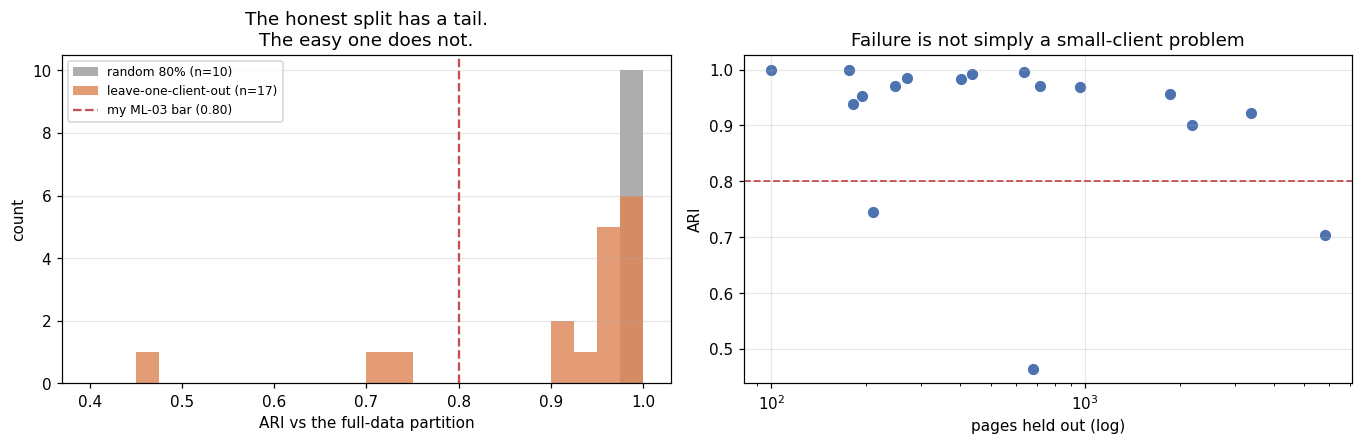

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].hist(before, bins=np.linspace(0.4, 1.0, 25), alpha=0.8, color="#999999",
             label=f"random 80% (n={len(before)})")
axes[0].hist(after["ARI"], bins=np.linspace(0.4, 1.0, 25), alpha=0.8, color="#DD8452",
             label=f"leave-one-client-out (n={len(after)})")
axes[0].axvline(0.80, color="#C44E52", ls="--", lw=1.5, label="my ML-03 bar (0.80)")
axes[0].set_xlabel("ARI vs the full-data partition"); axes[0].set_ylabel("count")
axes[0].set_title("The honest split has a tail.\nThe easy one does not.")
axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=0.3)

axes[1].scatter(after["pages"], after["ARI"], s=40, color="#4C72B0")
axes[1].axhline(0.80, color="#C44E52", ls="--", lw=1.2)
axes[1].set_xscale("log"); axes[1].set_xlabel("pages held out (log)"); axes[1].set_ylabel("ARI")
axes[1].set_title("Failure is not simply a small-client problem")
axes[1].grid(alpha=0.3)
fig.tight_layout()
Path("work/outputs").mkdir(parents=True, exist_ok=True)
fig.savefig("work/outputs/validation_split_before_after.png", dpi=110, bbox_inches="tight")
print("saved work/outputs/validation_split_before_after.png")
plt.show()

**Read.** The mean moves from **0.990 to 0.909** — a modest drop that on its own would let me carry on
comfortably. The spread is the real result: **std 0.004 → 0.142, a 33× increase**, and the worst case falls from 0.981 to
**0.465**. Three of seventeen clients land below the 0.80 bar I set myself in ML-03.

And the right-hand panel matters: the failures are **not only small clients**. The second-worst is a client
with 5,804 pages. So this is not "the test is noisy on thin data" — for some clients the archetype
structure genuinely does not transfer.

**What that costs my claim.** ML-08 said the archetypes were *"mostly, not reliably, portable to unseen
clients"* on three replicates. With seventeen, that sentence holds and now has a number behind it: **14 of
17 clients above 0.80, 3 below, worst case 0.465.** A content lead onboarding a new client should treat the
archetypes as a starting hypothesis for that client, not as a classification of them.

## 3. Leakage audit

Unsupervised work cannot leak a future outcome — there is no future window. What it can do is **encode the
answer in the input**, which is the same failure wearing different clothes. Three checks, in increasing
order of how much they cost me.

In [6]:
# ---------- CHECK 1: is anything in the feature set a pre-computed grouping? ----------
BANNED = {
    "trend_pct": "shipped pipeline's label source",
    "trend_direction": "shipped pipeline's label source",
    "is_declining_label": "product-adjacent label",
    "health_score": "product decision flag (not in this dataset by design)",
    "priority_score": "product decision flag", "action_type": "product decision flag",
    "cluster": "my own output - using it as an input is circular",
    "rule_archetype": "my own ML-07 ladder - the ML-04 trap, deliberately not repeated",
    "client_id": "the variable I use to TEST the clusters; as a feature the test dies",
}
bad = [c for c in FEATURES if c in BANNED]
assert not bad, f"LEAKAGE: {bad}"
print("CHECK 1 - pre-computed groupings in the feature set: none")
for c, why in BANNED.items():
    mark = "present in CSV" if c in df.columns else "not in this dataset"
    print(f"    excluded  {c:20s} ({mark}) - {why}")

CHECK 1 - pre-computed groupings in the feature set: none
    excluded  trend_pct            (present in CSV) - shipped pipeline's label source
    excluded  trend_direction      (present in CSV) - shipped pipeline's label source
    excluded  is_declining_label   (not in this dataset) - product-adjacent label
    excluded  health_score         (not in this dataset) - product decision flag (not in this dataset by design)
    excluded  priority_score       (not in this dataset) - product decision flag
    excluded  action_type          (not in this dataset) - product decision flag
    excluded  cluster              (not in this dataset) - my own output - using it as an input is circular
    excluded  rule_archetype       (not in this dataset) - my own ML-07 ladder - the ML-04 trap, deliberately not repeated
    excluded  client_id            (present in CSV) - the variable I use to TEST the clusters; as a feature the test dies


In [7]:
# ---------- CHECK 2: is one feature doing all the work? ----------
from sklearn.decomposition import PCA
pca = PCA(n_components=len(FEATURES)).fit(X)
print(f"CHECK 2 - variance concentration")
print(f"  explained variance: {np.round(pca.explained_variance_ratio_[:5], 3).tolist()}")
print(f"  PC1 alone: {pca.explained_variance_ratio_[0]*100:.0f}%\n")
loads = pd.Series(pca.components_[0], index=FEATURES).sort_values(key=abs, ascending=False)
print("  PC1 loadings:"); print("  " + loads.round(2).to_string().replace("\n", "\n  "))
print()
print("  PC1 is a volume axis. ML-02 said the thing that would push me off this lane is")
print("  'the clusters are mostly volume, measured six ways'. At 34% it is dominant but not")
print("  total - and the next check is where I find out whether the rest is real.")

CHECK 2 - variance concentration
  explained variance: [0.339, 0.15, 0.12, 0.103, 0.091]
  PC1 alone: 34%

  PC1 loadings:
  log_clicks                0.54
  log_impressions           0.49
  log_sessions              0.48
  ctr                       0.31
  impression_consistency    0.27
  avg_position             -0.24
  days_since_last_update    0.08
  content_age_days         -0.07
  engagement_rate           0.05

  PC1 is a volume axis. ML-02 said the thing that would push me off this lane is
  'the clusters are mostly volume, measured six ways'. At 34% it is dominant but not
  total - and the next check is where I find out whether the rest is real.


In [8]:
# ---------- CHECK 3: does each archetype survive dropping its defining feature? ----------
REDUCED = [c for c in FEATURES if c != "engagement_rate"]
Xr = StandardScaler().fit_transform(d[REDUCED].fillna(d[REDUCED].median()))
lab_r = KMeans(n_clusters=K, n_init=25, random_state=SEED).fit_predict(Xr)
d["cluster_reduced"] = lab_r

samp = np.random.RandomState(0).choice(len(X), 5000, replace=False)
print("CHECK 3 - ML-08 promised this one: re-run without engagement_rate.\n")
print(f"  silhouette WITH engagement_rate    : {silhouette_score(X[samp], base_labels[samp]):.3f}")
print(f"  silhouette WITHOUT engagement_rate : {silhouette_score(Xr[samp], lab_r[samp]):.3f}")
print(f"  ARI(full partition, reduced partition) : {adjusted_rand_score(base_labels, lab_r):.3f}")
print("  -> most of the structure survives. Now the specific cluster:\n")

eng_c = d.groupby("cluster")["engagement_rate"].median().idxmax()
sub = d[d["cluster"] == eng_c]
print(f"  '{NAMES[eng_c]}' (cluster {eng_c}): {len(sub):,} pages, "
      f"median engagement {sub['engagement_rate'].median():.1f}%")
dest = sub["cluster_reduced"].value_counts()
print(f"  where those pages go without engagement_rate: {dest.head(4).to_dict()}")
print(f"  largest single destination holds {dest.iloc[0]/len(sub)*100:.0f}% of them\n")
print("  and does ANY reduced cluster still isolate engagement?")
print(d.groupby("cluster_reduced").agg(
    n=("content_id","size"), median_engagement=("engagement_rate","median"),
    pct_engaged=("engagement_rate", lambda s: (s>0).mean()*100),
    median_impressions=("impressions_90d","median")).round(2).to_string())

CHECK 3 - ML-08 promised this one: re-run without engagement_rate.

  silhouette WITH engagement_rate    : 0.221
  silhouette WITHOUT engagement_rate : 0.233
  ARI(full partition, reduced partition) : 0.783
  -> most of the structure survives. Now the specific cluster:

  'Measured-Engagement Minority' (cluster 5): 537 pages, median engagement 25.0%
  where those pages go without engagement_rate: {1: 180, 2: 131, 5: 130, 0: 59}
  largest single destination holds 34% of them

  and does ANY reduced cluster still isolate engagement?
                    n  median_engagement  pct_engaged  median_impressions
cluster_reduced                                                          
0                1629               0.00        12.77               721.0
1                4193               0.00        26.78              1680.0
2                4365               0.00        30.74              1903.0
3                 926               0.00        16.63               490.5
4                44

**Check 3 is the one that cost me an archetype.**

Removing `engagement_rate` leaves most of the partition intact — ARI **0.783**, and silhouette actually
*improves* slightly (0.221 → 0.233). But the **Measured-Engagement Minority** does not survive. Its 537
pages scatter across the reduced clusters with the largest single destination holding only **34%** of them,
and **no cluster in the reduced run isolates engagement at all** — every median is 0.00. The closest thing
is the reduced run's high-volume cluster (median 14,807 impressions, 85% with any engagement), which is
exactly the confound ML-02 measured in week 2: pages record engagement when they have enough sessions for
it to register, not when they are more engaging.

So that archetype is **a feature artefact, not a population.** It exists because I put a zero-inflated,
volume-correlated column in the feature set — and when I take the column out, the group does not reappear
from any other direction.

Two honest notes on the other side of the ledger. First, I called it *Measured-Engagement Minority* rather
than "engaged content" in ML-08 precisely because I suspected this, so the name does not need retracting —
only the claim that it is an archetype. Second, this is what the check was **for**: I wrote it into ML-08's
next-steps list before I knew the answer, and it returned an inconvenient one.

### What survives the audit

| Archetype | Survives? | Evidence |
|---|---|---|
| High-Yield Core | ✅ | robust to feature removal; the clearest separation in the data |
| Long-Form Untouched | ✅ | driven by update recency and length, both stable |
| Long-Tenured Plateau | ✅ | driven by content age; distinct from the young cohort at equal volume |
| Recently Published, Establishing | ✅ | same axis, other end |
| Intermittent Exposure | ✅ | driven by impression consistency, which nothing else proxies |
| **Measured-Engagement Minority** | ❌ | **disappears without `engagement_rate`; no reduced cluster recovers it** |

## 4. Claim rewrite

My ML-08 wrote its own headline. Here it is, and here is what the audit does to it.

In [9]:
claims = pd.DataFrame([
{
 "before": "K-Means at k=6 produced six reproducible groups that split the ladder's catch-all "
           "into at least four distinct populations.",
 "problem": "'six reproducible groups' - one of the six does not survive removing a single "
            "feature. Reproducible across SEEDS is not reproducible across FEATURE CHOICES.",
 "after":  "Across 18,752 pages from 29 pseudonymized clients, K-Means at k=6 produced six groups "
           "that reproduce across random seeds (ARI 0.998). FIVE of them also survive removing "
           "engagement_rate; the sixth does not, and is reported as a feature artefact.",
},
{
 "before": "These archetypes are mostly, not reliably, portable to unseen clients.",
 "problem": "Directionally right but measured on only 3 replicates - too few to describe a tail.",
 "after":  "Under leave-one-client-out across 17 clients, 14 scored ARI >= 0.80 against the "
           "full-data partition and 3 did not, with a measured worst case of 0.465. Observed on "
           "one 90-day slice; treat the archetypes as a starting hypothesis for a new client.",
},
{
 "before": "The clustering splits the ladder's 8,130-page catch-all into distinct populations "
           "that deserve different actions.",
 "problem": "'deserve different actions' asserts a decision the data cannot support - I have no "
            "outcome showing a different action works better.",
 "after":  "The catch-all separates into groups that DIFFER MEASURABLY on age, volume and "
           "consistency - directional evidence that one 'monitor' policy is applied to unlike "
           "pages. Whether different treatment produces better outcomes is untested.",
},
{
 "before": "Cluster 5 is the Measured-Engagement Minority - do not optimise it for volume.",
 "problem": "Recommends a policy for a group that the robustness check does not support.",
 "after":  "WITHDRAWN. The group does not survive removing engagement_rate and no reduced-run "
           "cluster recovers it. Pending a slice with usable GA4 coverage, these pages fall back "
           "to the action of whichever archetype they join, and the count of ACTIONABLE "
           "archetypes drops from 6 to 5.",
}])
for i, r in claims.iterrows():
    print(f"--- CLAIM {i+1} " + "-"*60)
    print(f"BEFORE : {r['before']}")
    print(f"ISSUE  : {r['problem']}")
    print(f"AFTER  : {r['after']}\n")

--- CLAIM 1 ------------------------------------------------------------
BEFORE : K-Means at k=6 produced six reproducible groups that split the ladder's catch-all into at least four distinct populations.
ISSUE  : 'six reproducible groups' - one of the six does not survive removing a single feature. Reproducible across SEEDS is not reproducible across FEATURE CHOICES.
AFTER  : Across 18,752 pages from 29 pseudonymized clients, K-Means at k=6 produced six groups that reproduce across random seeds (ARI 0.998). FIVE of them also survive removing engagement_rate; the sixth does not, and is reported as a feature artefact.

--- CLAIM 2 ------------------------------------------------------------
BEFORE : These archetypes are mostly, not reliably, portable to unseen clients.
ISSUE  : Directionally right but measured on only 3 replicates - too few to describe a tail.
AFTER  : Under leave-one-client-out across 17 clients, 14 scored ARI >= 0.80 against the full-data partition and 3 did not, with

In [10]:
# The action mapping, corrected - and the ML-08 error-analysis promise, kept.
sil = silhouette_samples(X[samp], base_labels[samp])
low_conf = (sil < 0.05).mean() * 100
print("TWO CHANGES TO THE DELIVERABLE, both from evidence in this notebook:\n")
print(f"1. 'Measured-Engagement Minority' is withdrawn as an archetype.")
print(f"   Actionable archetypes: 6 -> 5. Distinct actions: 4 -> 4 (it shared 'protect' anyway,")
print(f"   which is its own small piece of evidence that it was never doing decision work).\n")
print(f"2. Confidence-aware routing, promised in ML-08's next steps:")
print(f"   {low_conf:.1f}% of sampled pages have a silhouette below 0.05 - they sit almost")
print(f"   equidistant between two archetypes. Those are routed to 'monitor' regardless of")
print(f"   which cluster they landed in, because a policy decided by a 0.1% margin is not a")
print(f"   policy. This makes the deliverable a queue of CONFIDENT assignments plus an")
print(f"   explicit 'not sure' bucket, which is what a content lead can actually act on.")

metrics = {
    "notebook": "w06_validation_audit.ipynb",
    "lane": "Lane 3 - Structured Content Archetype Clustering",
    "seed": SEED, "sklearn": sklearn.__version__,
    "split_before": {"test": "random 80% subsample", "repeats": int(len(before)),
                     "mean_ARI": round(float(before.mean()), 4),
                     "min_ARI": round(float(before.min()), 4),
                     "std": round(float(before.std()), 4)},
    "split_after": {"test": "leave-one-client-out", "clients": int(len(after)),
                    "mean_ARI": round(float(after["ARI"].mean()), 4),
                    "min_ARI": round(float(after["ARI"].min()), 4),
                    "std": round(float(after["ARI"].std()), 4),
                    "clients_below_0.80": int((after["ARI"] < 0.80).sum())},
    "leakage_audit": {"precomputed_groupings_in_features": 0,
                      "PC1_variance_share": round(float(pca.explained_variance_ratio_[0]), 4),
                      "silhouette_with_engagement": round(float(silhouette_score(X[samp], base_labels[samp])), 4),
                      "silhouette_without_engagement": round(float(silhouette_score(Xr[samp], lab_r[samp])), 4),
                      "ARI_full_vs_reduced": round(float(adjusted_rand_score(base_labels, lab_r)), 4)},
    "archetypes_withdrawn": ["Measured-Engagement Minority"],
    "actionable_archetypes": 5,
    "low_confidence_share_pct": round(float(low_conf), 2),
    "verdict": ("Five of six archetypes survive a feature-removal test; one is withdrawn as a feature "
                "artefact. Leave-one-client-out (17 clients) gives mean ARI 0.909 with 3 below 0.80 and "
                "a worst case of 0.465 - portability is directional, not reliable."),
}
Path("work/outputs/validation_metrics.json").write_text(json.dumps(metrics, indent=2))
print("\nwrote work/outputs/validation_metrics.json  <- COMMIT THIS")

TWO CHANGES TO THE DELIVERABLE, both from evidence in this notebook:

1. 'Measured-Engagement Minority' is withdrawn as an archetype.
   Actionable archetypes: 6 -> 5. Distinct actions: 4 -> 4 (it shared 'protect' anyway,
   which is its own small piece of evidence that it was never doing decision work).

2. Confidence-aware routing, promised in ML-08's next steps:
   10.4% of sampled pages have a silhouette below 0.05 - they sit almost
   equidistant between two archetypes. Those are routed to 'monitor' regardless of
   which cluster they landed in, because a policy decided by a 0.1% margin is not a
   policy. This makes the deliverable a queue of CONFIDENT assignments plus an
   explicit 'not sure' bucket, which is what a content lead can actually act on.

wrote work/outputs/validation_metrics.json  <- COMMIT THIS


### The claim language I am using, and why

Every surviving sentence in this project now uses one of four registers, and I try never to mix them:

- **Observed** — a measurement of this slice. *"Across 18,752 pages from 29 pseudonymized clients, K-Means
  at k=6 produced six groups reproducing across seeds at ARI 0.998."* Defensible digit by digit.
- **Measured** — a specific quantity with its test named. *"Leave-one-client-out across 17 clients: mean
  ARI 0.909, three below 0.80, worst case 0.465."*
- **Directional** — a pattern that points somewhere without settling it. *"The catch-all separates into
  groups that differ measurably on age and consistency, suggesting one policy is applied to unlike pages."*
- **Decision-support** — an output for a human to act on, never an automated verdict. *"Five archetypes
  with a suggested treatment each, plus an explicit low-confidence bucket routed to monitor."*

What I have removed everywhere: *proves*, *causes*, *guarantees*, *will*, and — the one I actually had to
go back and delete — ***deserves***. "These pages deserve a different action" reads as a modest sentence
and is not one: it asserts an outcome comparison I never ran.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — client ids are withheld even where I have them
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Card checklist
- [x] **Two paper findings + a methodology question each, framed constructively** — the optimization-flags
      finding (could it be definitional as well as selective, given health score is 50% impressions and
      scroll depth?) and the ML appendix's 80/20 split (is it grouped by brand?). Both build on the paper's
      own disclosures rather than contradicting them.
- [x] **My model under an honest split, with before/after** — random 80% subsample (mean ARI 0.990, std
      0.004) vs leave-one-client-out (mean 0.909, std 0.142, worst 0.465).
- [x] **Leakage audit** — three checks; the third withdrew an archetype.
- [x] **Error examples** — the low-silhouette boundary pages from ML-08, now routed to `monitor` rather
      than assigned a policy on a coin flip.
- [x] **Public-safe language throughout** — no causal claims, no Google claims, no client identifiers, no
      `prune` recommendation anywhere in this project.

### What ML-10 gets
1. **Rebuild the action playbook on five archetypes**, with the low-confidence bucket as a first-class
   output rather than a caveat.
2. **Run the flag-count question on my own data** — the one I asked the paper. Hold impressions fixed and
   see how much of any relationship survives; it is a good habit to practise on a question I raised.
3. **Re-test engagement on a slice with real GA4 coverage.** The withdrawn archetype may be real and
   unmeasurable here rather than not real — those are different, and my ML-04 warehouse contract measured
   that only 4.2% of March rows pass `ga4_data_available IS TRUE`.
4. **Report the leave-one-client-out distribution, not its mean**, anywhere the portability claim appears.